In [1]:
!pip install yfinance ta -q

import yfinance as yf
import pandas as pd
import ta
import matplotlib.pyplot as plt

  Preparing metadata (setup.py) ... done


In [2]:
def fetch_stock_data(ticker: str, period: str = "2y") -> pd.DataFrame:
    try:
        t = yf.Ticker(ticker)
        df = t.history(period=period)
        if df.empty:
            raise ValueError(f"No data found for ticker: {ticker}")
        df = df.drop(columns=['Dividends', 'Stock Splits'])
        df.index = df.index.tz_localize(None)
        df = df.ffill()
        return df
    except Exception as e:
        print(f"Error fetching {ticker}: {e}")
        return pd.DataFrame()

df = fetch_stock_data("RELIANCE.NS")
print(df.shape)
print(df.tail(3))

(498, 5)
                   Open         High          Low        Close    Volume
Date                                                                    
2026-05-20  1318.699951  1362.900024  1312.599976  1359.699951  13248515
2026-05-21  1367.199951  1370.900024  1345.199951  1349.599976  17150630
2026-05-22  1350.000000  1367.400024  1349.099976  1354.500000   7105813


In [3]:
# RSI — Relative Strength Index
# length=14 means it looks at the last 14 trading days
# this is the industry standard period

df['RSI'] = ta.momentum.RSIIndicator(
    close=df['Close'], 
    window=14
).rsi()

# check the last 10 values
print(df['RSI'].tail(10))
print(f"\nCurrent RSI: {df['RSI'].iloc[-1]:.2f}")
print(f"Max RSI in 2 years: {df['RSI'].max():.2f}")
print(f"Min RSI in 2 years: {df['RSI'].min():.2f}")
print(f"NaN values: {df['RSI'].isna().sum()}")

Date
2026-05-11    48.088320
2026-05-12    43.610320
2026-05-13    42.690412
2026-05-14    43.431781
2026-05-15    38.849422
2026-05-18    38.762723
2026-05-19    36.450017
2026-05-20    46.148693
2026-05-21    44.167167
2026-05-22    45.392227
Name: RSI, dtype: float64

Current RSI: 45.39
Max RSI in 2 years: 79.27
Min RSI in 2 years: 23.93
NaN values: 13


In [4]:
# MACD
macd_indicator = ta.trend.MACD(
    close=df['Close'],
    window_slow=26,    # slow EMA — industry standard
    window_fast=12,    # fast EMA — industry standard  
    window_sign=9      # signal line — industry standard
)

df['MACD'] = macd_indicator.macd()
df['MACD_signal'] = macd_indicator.macd_signal()
df['MACD_histogram'] = macd_indicator.macd_diff()

print(df[['MACD', 'MACD_signal', 'MACD_histogram']].tail(10))
print(f"\nCurrent MACD: {df['MACD'].iloc[-1]:.4f}")
print(f"Current Signal: {df['MACD_signal'].iloc[-1]:.4f}")
print(f"Current Histogram: {df['MACD_histogram'].iloc[-1]:.4f}")
print(f"NaN values in MACD: {df['MACD'].isna().sum()}")

                 MACD  MACD_signal  MACD_histogram
Date                                              
2026-05-11  16.362586    12.724201        3.638385
2026-05-12  11.156048    12.410570       -1.254522
2026-05-13   6.534905    11.235437       -4.700532
2026-05-14   3.079197     9.604189       -6.524992
2026-05-15  -1.689571     7.345437       -9.035008
2026-05-18  -5.446416     4.787067      -10.233483
2026-05-19  -9.380743     1.953505      -11.334248
2026-05-20  -9.404723    -0.318141       -9.086582
2026-05-21 -10.122031    -2.278919       -7.843112
2026-05-22 -10.177788    -3.858693       -6.319095

Current MACD: -10.1778
Current Signal: -3.8587
Current Histogram: -6.3191
NaN values in MACD: 25


In [5]:
# Bollinger Bands
bb_indicator = ta.volatility.BollingerBands(
    close=df['Close'],
    window=20,      # 20-day moving average — industry standard
    window_dev=2    # 2 standard deviations — industry standard
)

df['BB_upper'] = bb_indicator.bollinger_hband()
df['BB_mid'] = bb_indicator.bollinger_mavg()    # this is just the 20-day SMA
df['BB_lower'] = bb_indicator.bollinger_lband()
df['BB_width'] = bb_indicator.bollinger_wband()  # width — useful for detecting squeeze

print(df[['Close', 'BB_upper', 'BB_mid', 'BB_lower', 'BB_width']].tail(10))
print(f"\nCurrent price: {df['Close'].iloc[-1]:.2f}")
print(f"Upper band: {df['BB_upper'].iloc[-1]:.2f}")
print(f"Mid band: {df['BB_mid'].iloc[-1]:.2f}")
print(f"Lower band: {df['BB_lower'].iloc[-1]:.2f}")
print(f"\nPrice position: {'Above mid' if df['Close'].iloc[-1] > df['BB_mid'].iloc[-1] else 'Below mid'}")

                  Close     BB_upper       BB_mid     BB_lower   BB_width
Date                                                                     
2026-05-11  1388.199951  1480.589653  1389.165009  1297.740365  13.162532
2026-05-12  1364.000000  1477.424246  1391.610010  1305.795774  12.333087
2026-05-13  1358.800049  1476.759350  1392.345013  1307.930677  12.125491
2026-05-14  1361.800049  1475.900970  1393.270013  1310.639057  11.861442
2026-05-15  1336.400024  1477.319227  1391.840015  1306.360802  12.282908
2026-05-18  1335.900024  1478.573014  1390.470013  1302.367013  12.672406
2026-05-19  1322.699951  1480.564296  1388.940009  1297.315721  13.193412
2026-05-20  1359.699951  1480.590761  1388.820007  1297.049254  13.215644
2026-05-21  1349.599976  1480.325038  1389.130005  1297.934972  13.129805
2026-05-22  1354.500000  1478.765512  1390.465002  1302.164493  12.700860

Current price: 1354.50
Upper band: 1478.77
Mid band: 1390.47
Lower band: 1302.16

Price position: Below mid


In [6]:
# Simple Moving Averages
df['SMA_50'] = ta.trend.SMAIndicator(close=df['Close'], window=50).sma_indicator()
df['SMA_200'] = ta.trend.SMAIndicator(close=df['Close'], window=200).sma_indicator()

# Golden cross / death cross detection
# Golden cross = SMA50 crosses above SMA200 = strong bullish signal
# Death cross = SMA50 crosses below SMA200 = strong bearish signal
current_sma50 = df['SMA_50'].iloc[-1]
current_sma200 = df['SMA_200'].iloc[-1]

print(f"Current price:   {df['Close'].iloc[-1]:.2f}")
print(f"SMA 50:          {current_sma50:.2f}")
print(f"SMA 200:         {current_sma200:.2f}")
print(f"\nPrice vs SMA50:  {'Above' if df['Close'].iloc[-1] > current_sma50 else 'Below'}")
print(f"Price vs SMA200: {'Above' if df['Close'].iloc[-1] > current_sma200 else 'Below'}")
print(f"SMA50 vs SMA200: {'Golden Cross (bullish)' if current_sma50 > current_sma200 else 'Death Cross (bearish)'}")
print(f"\nNaN in SMA50:  {df['SMA_50'].isna().sum()}")
print(f"NaN in SMA200: {df['SMA_200'].isna().sum()}")

Current price:   1354.50
SMA 50:          1375.61
SMA 200:         1429.81

Price vs SMA50:  Below
Price vs SMA200: Below
SMA50 vs SMA200: Death Cross (bearish)

NaN in SMA50:  49
NaN in SMA200: 199


In [7]:
# EMA — Exponential Moving Average
# Gives more weight to recent prices than SMA
# EMA reacts faster to price changes

df['EMA_12'] = ta.trend.EMAIndicator(close=df['Close'], window=12).ema_indicator()
df['EMA_26'] = ta.trend.EMAIndicator(close=df['Close'], window=26).ema_indicator()

print(df[['Close', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26']].tail(5))
print(f"\nNaN in EMA12: {df['EMA_12'].isna().sum()}")
print(f"NaN in EMA26: {df['EMA_26'].isna().sum()}")

                  Close       SMA_50      SMA_200       EMA_12       EMA_26
Date                                                                       
2026-05-18  1335.900024  1379.140005  1430.795790  1377.076940  1382.523356
2026-05-19  1322.699951  1378.694004  1430.478472  1368.711250  1378.091993
2026-05-20  1359.699951  1378.100002  1430.366571  1367.324896  1376.729620
2026-05-21  1349.599976  1376.996001  1430.057257  1364.597985  1374.720016
2026-05-22  1354.500000  1375.606001  1429.807304  1363.044449  1373.222237

NaN in EMA12: 11
NaN in EMA26: 25


In [8]:
print("All columns in dataframe:")
print(df.columns.tolist())
print(f"\nDataframe shape: {df.shape}")
print(f"\nFirst date with all indicators (no NaN): {df.dropna().index[0].date()}")
print(f"Total clean rows (no NaN anywhere): {df.dropna().shape[0]}")

All columns in dataframe:
['Open', 'High', 'Low', 'Close', 'Volume', 'RSI', 'MACD', 'MACD_signal', 'MACD_histogram', 'BB_upper', 'BB_mid', 'BB_lower', 'BB_width', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26']

Dataframe shape: (498, 17)

First date with all indicators (no NaN): 2025-03-06
Total clean rows (no NaN anywhere): 299


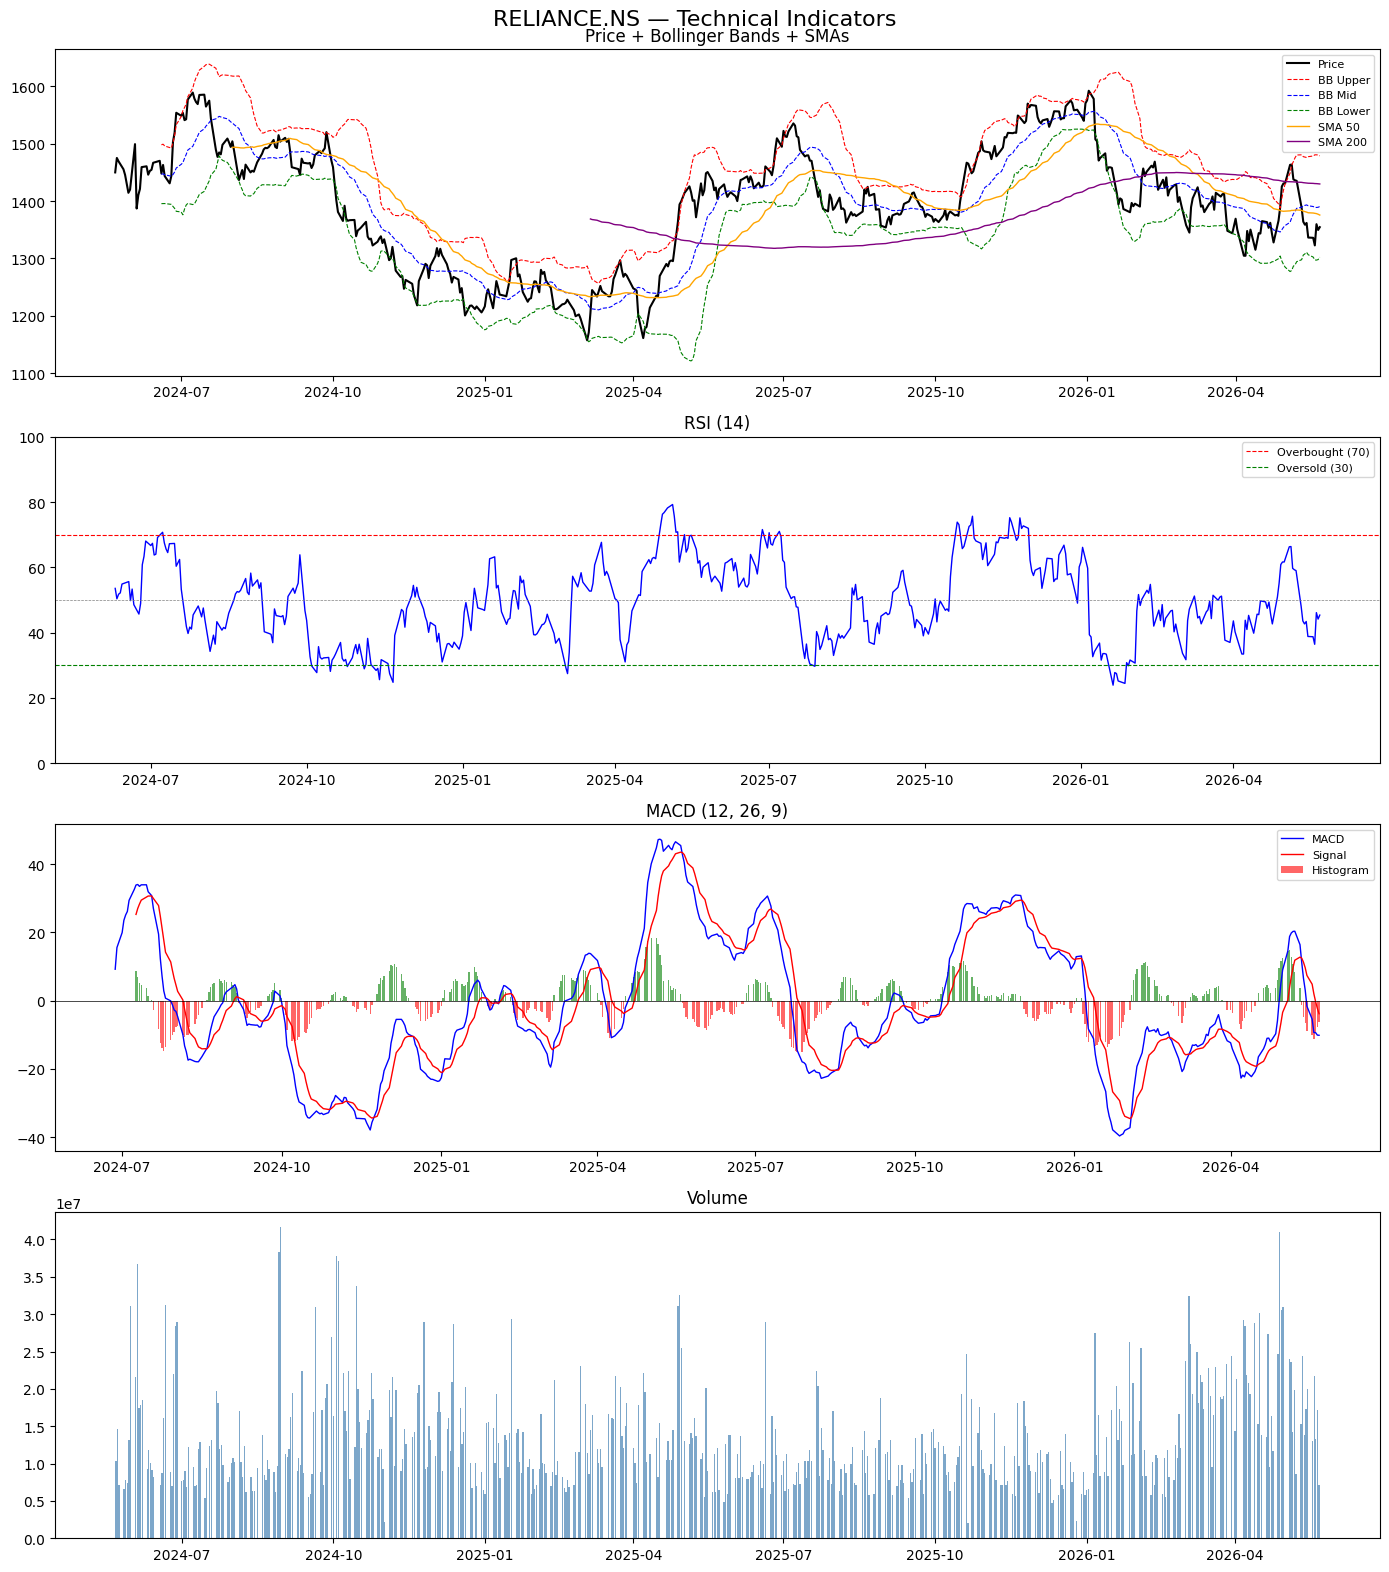

In [9]:
# plot all indicators to visually verify they look correct
fig, axes = plt.subplots(4, 1, figsize=(14, 16))
fig.suptitle('RELIANCE.NS — Technical Indicators', fontsize=16)

# 1. Price + Bollinger Bands + SMAs
axes[0].plot(df.index, df['Close'], label='Price', color='black', linewidth=1.5)
axes[0].plot(df.index, df['BB_upper'], label='BB Upper', color='red', linewidth=0.8, linestyle='--')
axes[0].plot(df.index, df['BB_mid'], label='BB Mid', color='blue', linewidth=0.8, linestyle='--')
axes[0].plot(df.index, df['BB_lower'], label='BB Lower', color='green', linewidth=0.8, linestyle='--')
axes[0].plot(df.index, df['SMA_50'], label='SMA 50', color='orange', linewidth=1)
axes[0].plot(df.index, df['SMA_200'], label='SMA 200', color='purple', linewidth=1)
axes[0].legend(fontsize=8)
axes[0].set_title('Price + Bollinger Bands + SMAs')

# 2. RSI
axes[1].plot(df.index, df['RSI'], color='blue', linewidth=1)
axes[1].axhline(y=70, color='red', linestyle='--', linewidth=0.8, label='Overbought (70)')
axes[1].axhline(y=30, color='green', linestyle='--', linewidth=0.8, label='Oversold (30)')
axes[1].axhline(y=50, color='gray', linestyle='--', linewidth=0.5)
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=8)
axes[1].set_title('RSI (14)')

# 3. MACD
axes[2].plot(df.index, df['MACD'], label='MACD', color='blue', linewidth=1)
axes[2].plot(df.index, df['MACD_signal'], label='Signal', color='red', linewidth=1)
axes[2].bar(df.index, df['MACD_histogram'], label='Histogram', 
            color=['green' if x >= 0 else 'red' for x in df['MACD_histogram']], alpha=0.6)
axes[2].axhline(y=0, color='black', linewidth=0.5)
axes[2].legend(fontsize=8)
axes[2].set_title('MACD (12, 26, 9)')

# 4. Volume
axes[3].bar(df.index, df['Volume'], color='steelblue', alpha=0.7)
axes[3].set_title('Volume')

plt.tight_layout()
plt.show()